In [1]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 372s 2us/step


In [4]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)
print('x_train shape: ',x_train.shape)
print('x_train test: ',x_test.shape)

x_train shape:  (50000, 32, 32, 3)
x_train test:  (10000, 32, 32, 3)


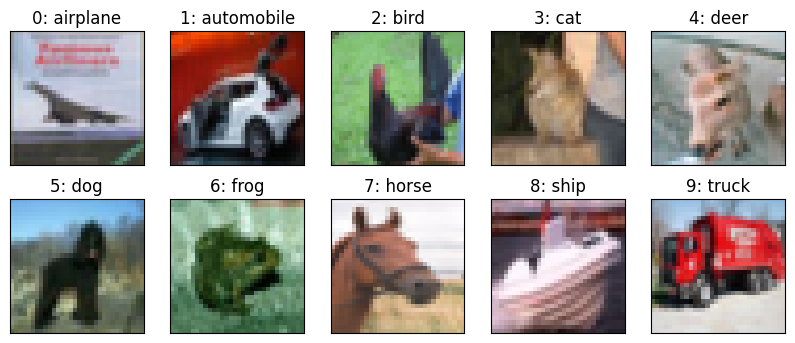

In [5]:
(_, _), (_, labels) = cifar10.load_data()
idx = [3, 6, 25, 46, 58, 85, 93, 99, 108, 133]
clsmap = {
    0:'airplane',
    1:'automobile',
    2:'bird',
    3:'cat',
    4: 'deer',
    5: 'dog',
    6:'frog',
    7:'horse',
    8:'ship',
    9:'truck'
}
plt.figure(figsize = (10,4))
for i, (img, y) in enumerate(zip(x_test[idx].reshape(10,32,32,3), labels[idx])):
  plt.subplot(2,5,i+1)
  plt.imshow(img,cmap='gray')
  plt.xticks([])
  plt.yticks([])
  plt.title(str(y[0]) + ": "+ clsmap[y[0]])
plt.show()

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam



classifier = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),


    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),



    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.35),


    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),


    layers.Dense(10, activation='softmax')
])

classifier.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,218,378 (4.65 MB)

 Trainable params: 1,216,074 (4.64 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [11]:
opt = Adam(learning_rate=0.001)

classifier.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=12,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_cifar10_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [13]:
from sklearn.model_selection import train_test_split

x_train_new, x_val, y_train_new, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=np.argmax(y_train, axis=1)
)

In [14]:
hist = classifier.fit(
    x_train_new,
    y_train_new,
    batch_size=128,
    epochs=100,
    validation_data=(x_val, y_val),
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint],
    shuffle=True,verbose=1)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3500 - loss: 1.9684
Epoch 1: val_accuracy improved from None to 0.11320, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 39s 70ms/step - accuracy: 0.4477 - loss: 1.6081 - val_accuracy: 0.1132 - val_loss: 4.4247 - learning_rate: 0.0010
Epoch 2/100
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6243 - loss: 1.0702
Epoch 2: val_accuracy improved from 0.11320 to 0.63240, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6450 - loss: 1.0057 - val_accuracy: 0.6324 - val_loss: 1.1240 - learning_rate: 0.0010
Epoch 3/100
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7138 - loss: 0.8165
Epoch 3: val_accuracy improved from 0.63240 to 0.75400, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to best_ci

In [15]:
test_loss, test_accuracy = classifier.evaluate(
    x_test,
    y_test,
    verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8876 - loss: 0.5358
Test Loss: 0.5358142852783203
Test Accuracy: 0.8876000046730042


In [16]:
classifier.save_weights("cnn1.weights.h5")

In [17]:
classifier.load_weights('cnn1.weights.h5')

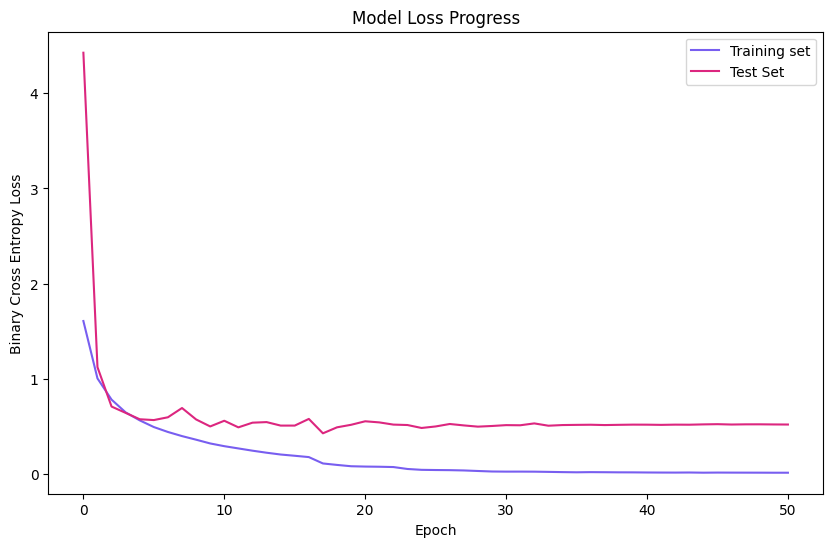

In [18]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,6))
plt.plot(hist.history['loss'], color='#785ef0')
plt.plot(hist.history['val_loss'], color='#dc267f')
plt.title('Model Loss Progress')
plt.ylabel('Binary Cross Entropy Loss')
plt.xlabel('Epoch')
plt.legend(['Training set','Test Set'], loc='upper right')
plt.show()

In [21]:
classifier.load_weights('cnn1.weights.h5')
classifier.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [22]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score
import numpy as np


y_hat = classifier.predict(x_test)

y_pred = np.argmax(y_hat, axis=1)

y_true = np.argmax(y_test, axis=1)


print("Classification Report:")
print(classification_report(y_true,y_pred,labels=list(range(10))))


cm = confusion_matrix(y_true,y_pred,labels=list(range(10)))

print("Confusion Matrix:")
print(cm)

balanced_acc = balanced_accuracy_score(y_true,y_pred)

print("Balanced Accuracy:", balanced_acc)

ber = 1 - balanced_acc

print("BER:", ber)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1000
           1       0.94      0.94      0.94      1000
           2       0.86      0.84      0.85      1000
           3       0.82      0.73      0.77      1000
           4       0.86      0.89      0.88      1000
           5       0.84      0.84      0.84      1000
           6       0.89      0.94      0.92      1000
           7       0.91      0.92      0.92      1000
           8       0.93      0.93      0.93      1000
           9       0.93      0.93      0.93      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Confusion Matrix:
[[906  12  23   7   5   2   3   4  29   9]
 [  7 945   0   1   2   0   1   2  12  30]
 [ 28   0 839  15  45  25  31  13   4   0]
 [ 12   1  37 726  40  95  48 

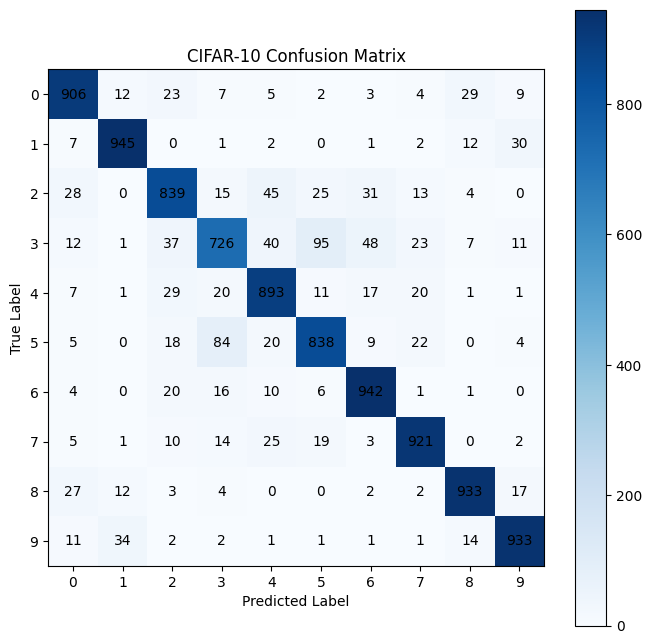

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 Confusion Matrix")

plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],ha="center",va="center")

plt.show()

Layer: conv2d_2
Original shape: (3, 3, 3, 64)


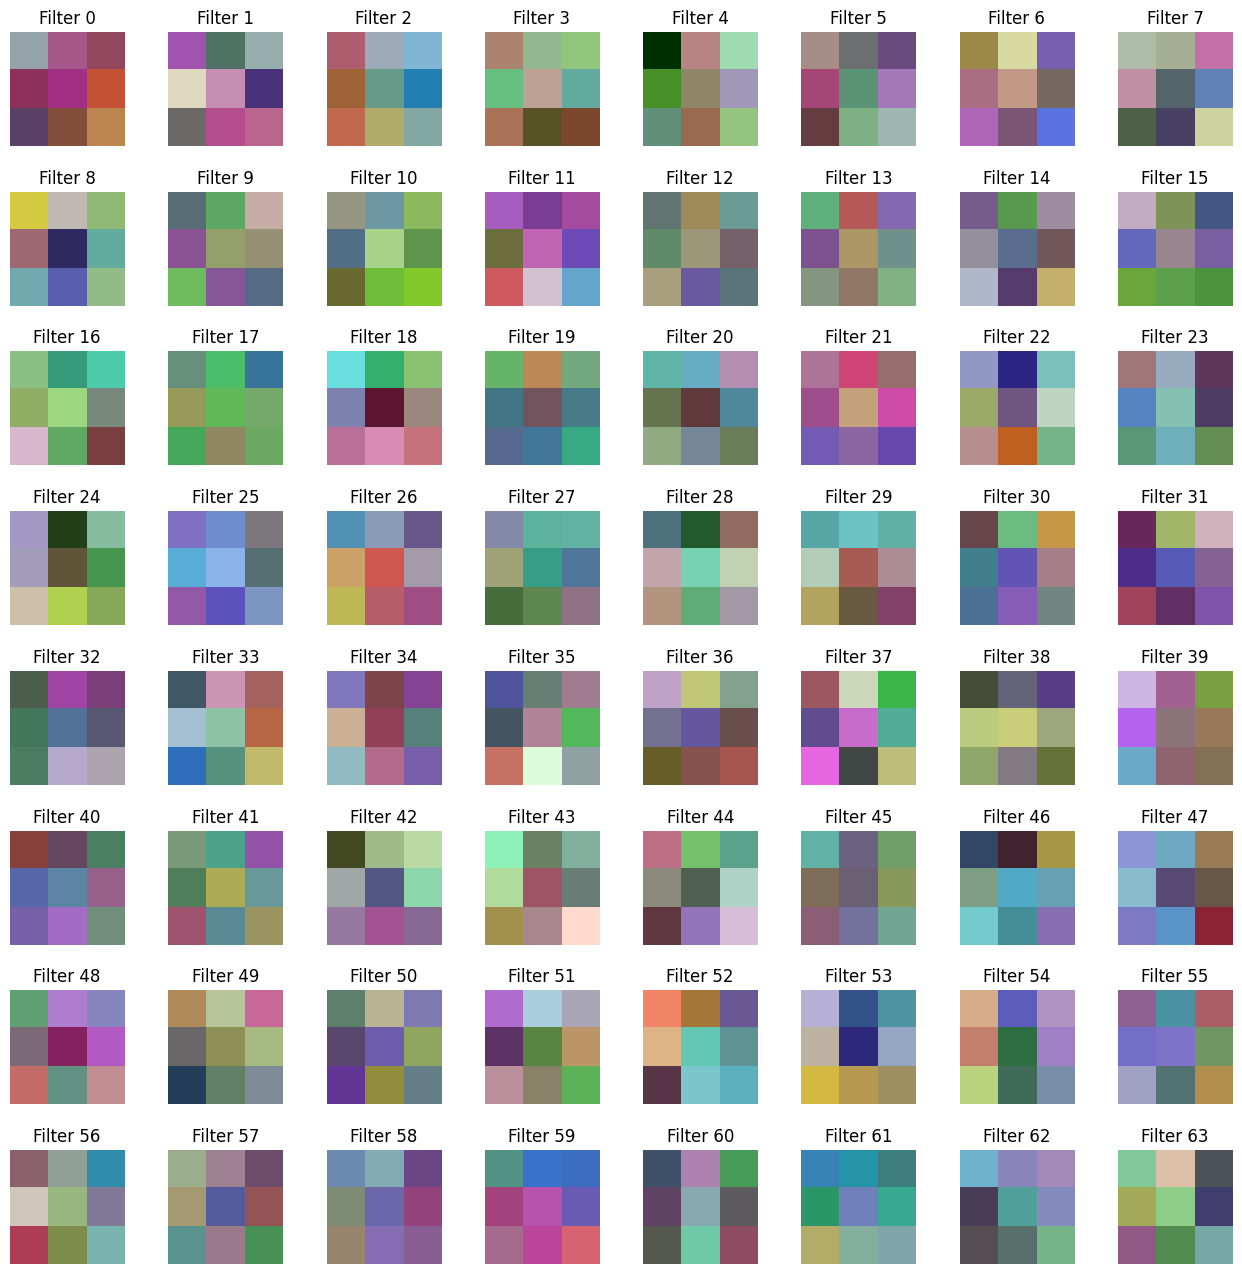

In [24]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Conv2D
import matplotlib.pyplot as plt
import numpy as np

# Get the first Conv2D layer
conv_layer = next(
    layer for layer in classifier.layers
    if isinstance(layer, Conv2D))

print("Layer:", conv_layer.name)

# Get filters
w = conv_layer.get_weights()[0]

print("Original shape:", w.shape)

# Scale weights to [0,1] for visualization
wshape = w.shape

scaler = MinMaxScaler()
w = scaler.fit_transform(w.reshape(-1, 1))

w = w.reshape(wshape)

# Display filters
fig, axs = plt.subplots(8, 8,figsize=(16, 16))

fig.subplots_adjust(hspace=0.4,wspace=0.2)

axs = axs.ravel()

for i in range(w.shape[-1]):

    # RGB filter
    h = w[:, :, :, i]
    axs[i].imshow(h)
    axs[i].set_title("Filter " + str(i))
    axs[i].axis("off")

plt.show()

In [25]:
classifier.save("cifar10_cnn_model.keras")

In [26]:
from google.colab import files

files.download("cifar10_cnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>